# Dubai Property Price Predictor

**Goal:** Train a machine learning model that predicts Dubai residential apartment sale prices using real Dubai Land Department (DLD) transaction data.

**Notebook structure:**
1. Imports & configuration
2. Load & initial inspection
3. Filtering — scope the problem
4. Missing value analysis & decisions
5. Feature selection
6. EDA & visualizations
7. Preprocessing & pipeline
8. Model comparison
9. Final model — train, evaluate, save
10. Sanity check — predict one property

---

## 1. Imports & Configuration

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import json
from pathlib import Path

# ── Data manipulation ─────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Model persistence ─────────────────────────────────────────────────────────
import joblib

# ── Scikit-learn: models ──────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# ── Scikit-learn: pipeline & preprocessing ────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer

# ── Learning curve for the best model ────────────────────────────────────────
from sklearn.model_selection import learning_curve

# ── Scikit-learn: model selection & metrics ───────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# ── XGBoost ───────────────────────────────────────────────────────────────────
from xgboost import XGBRegressor

# ── Display settings ──────────────────────────────────────────────────────────
pd.set_option('display.max_columns', None)   # show all columns in df.head()
sns.set_theme(style='whitegrid')             # clean plot backgrounds
plt.rcParams['figure.figsize'] = (12, 5)    # default figure size
plt.rcParams['font.size'] = 12

print('All imports successful ✓')

All imports successful ✓


## 2. Paths

In [2]:
# ── Project paths ─────────────────────────────────────────────────────────────
# Path(__file__) doesn't work in Jupyter, so we use Path.cwd() instead.
# This assumes the notebook is inside the /notebooks folder.
ROOT = Path.cwd().parent

DATA_PATH  = ROOT / 'data' / 'raw' / 'dubai_transactions.csv'   # raw dataset
CLEAN_PATH = ROOT / 'data' / 'raw' / 'dubai_clean.csv'          # filtered & cleaned
MODEL_PATH = ROOT / 'models' / 'model.joblib'                    # saved pipeline
META_PATH  = ROOT / 'models' / 'model_meta.json'                 # saved metrics

# Create models directory if it doesn't exist yet
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

print(f'ROOT       : {ROOT}')
print(f'DATA_PATH  : {DATA_PATH}')
print(f'MODEL_PATH : {MODEL_PATH}')

ROOT       : D:\dubai-property-predictor
DATA_PATH  : D:\dubai-property-predictor\data\raw\dubai_transactions.csv
MODEL_PATH : D:\dubai-property-predictor\models\model.joblib


## 3. Load & Initial Inspection

In [3]:
# ── Load raw data ─────────────────────────────────────────────────────────────
df_raw = pd.read_csv(DATA_PATH)

print(f'Shape  : {df_raw.shape}')         # (rows, columns)
print(f'Columns: {df_raw.columns.tolist()}')
df_raw.head(3)

Shape  : (1047965, 46)
Columns: ['transaction_id', 'procedure_id', 'trans_group_id', 'trans_group_ar', 'trans_group_en', 'procedure_name_ar', 'procedure_name_en', 'instance_date', 'property_type_id', 'property_type_ar', 'property_type_en', 'property_sub_type_id', 'property_sub_type_ar', 'property_sub_type_en', 'property_usage_ar', 'property_usage_en', 'reg_type_id', 'reg_type_ar', 'reg_type_en', 'area_id', 'area_name_ar', 'area_name_en', 'building_name_ar', 'building_name_en', 'project_number', 'project_name_ar', 'project_name_en', 'master_project_en', 'master_project_ar', 'nearest_landmark_ar', 'nearest_landmark_en', 'nearest_metro_ar', 'nearest_metro_en', 'nearest_mall_ar', 'nearest_mall_en', 'rooms_ar', 'rooms_en', 'has_parking', 'procedure_area', 'actual_worth', 'meter_sale_price', 'rent_value', 'meter_rent_price', 'no_of_parties_role_1', 'no_of_parties_role_2', 'no_of_parties_role_3']


,transaction_id,procedure_id,trans_group_id,trans_group_ar,trans_group_en,procedure_name_ar,procedure_name_en,instance_date,property_type_id,property_type_ar,property_type_en,property_sub_type_id,property_sub_type_ar,property_sub_type_en,property_usage_ar,property_usage_en,reg_type_id,reg_type_ar,reg_type_en,area_id,area_name_ar,area_name_en,building_name_ar,building_name_en,project_number,project_name_ar,project_name_en,master_project_en,master_project_ar,nearest_landmark_ar,nearest_landmark_en,nearest_metro_ar,nearest_metro_en,nearest_mall_ar,nearest_mall_en,rooms_ar,rooms_en,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3
0,1-11-2001-165,11,1,مبايعات,Sales,بيع,Sell,24-02-2001,1,أرض,Land,NaN,NaN,NaN,تجاري,Commercial,1,العقارات القائمة,Existing Properties,364,الوصل,Al Wasl,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1393.55,1350000.0,968.75,NaN,NaN,1.0,1.0,0.0
1,3-9-2004-223,9,3,هبات,Gifts,هبه,Grant,13-12-2004,4,فيلا,Villa,NaN,NaN,NaN,تجاري,Commercial,1,العقارات القائمة,Existing Properties,365,الحضيبه,Al Hudaiba,NaN,NaN,NaN,NaN,NaN,NaN,NaN,برج خليفة,Burj Khalifa,محطة مترو الجافلية,Al Jafiliya Metro Station,مول دبي,Dubai Mall,NaN,NaN,0,1728.00,2790000.0,1614.58,NaN,NaN,1.0,1.0,0.0
2,2-13-1996-119,13,2,رهون,Mortgages,تسجيل رهن,Mortgage Registration,12-03-2001,1,أرض,Land,NaN,NaN,NaN,تجاري,Commercial,1,العقارات القائمة,Existing Properties,390,برج خليفة,Burj Khalifa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,929.03,20000000.0,21527.83,NaN,NaN,1.0,1.0,0.0


In [4]:
# ── Data types & non-null counts ──────────────────────────────────────────────
# df.info() gives column names, non-null counts, and dtypes at a glance.
# Note: df.info('int64') was incorrect syntax — the argument is verbose, not dtype.
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1047965 entries, 0 to 1047964
Data columns (total 46 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   transaction_id        1047965 non-null  object 
 1   procedure_id          1047965 non-null  int64  
 2   trans_group_id        1047965 non-null  int64  
 3   trans_group_ar        1047965 non-null  object 
 4   trans_group_en        1047965 non-null  object 
 5   procedure_name_ar     1047965 non-null  object 
 6   procedure_name_en     1047965 non-null  object 
 7   instance_date         1047960 non-null  object 
 8   property_type_id      1047965 non-null  int64  
 9   property_type_ar      1047965 non-null  object 
 10  property_type_en      1047965 non-null  object 
 11  property_sub_type_id  807819 non-null   float64
 12  property_sub_type_ar  807819 non-null   object 
 13  property_sub_type_en  807819 non-null   object 
 14  property_usage_ar     1047965 non-

## 4. Filtering — Scope the Problem

The raw dataset contains Sales, Mortgages, Gifts, and other transaction types across
Land, Unit (apartments), and Villa property types.

**Decision:** We model **residential unit sales only** because:
- Mortgages/Gifts don't reflect true market price
- Land and commercial properties have completely different pricing dynamics
- Mixing them would confuse the model and reduce accuracy

In [5]:
# ── Start with a copy so raw data is never modified ───────────────────────────
df = df_raw.copy()

# ── Parse date column ─────────────────────────────────────────────────────────
df['instance_date'] = pd.to_datetime(df['instance_date'], dayfirst=True, errors='coerce')

# Extract year and month as separate numeric features for the model
df['year']  = df['instance_date'].dt.year
df['month'] = df['instance_date'].dt.month

# ── Filter: Sales transactions only ──────────────────────────────────────────
print(f'Before filter: {df.shape[0]:,} rows')
df = df[df['trans_group_en'] == 'Sales'].copy()
print(f'After Sales filter: {df.shape[0]:,} rows')

# ── Filter: Residential units only (apartments) ───────────────────────────────
df = df[df['property_type_en'] == 'Unit'].copy()
print(f'After Unit filter: {df.shape[0]:,} rows')

Before filter: 1,047,965 rows
After Sales filter: 787,892 rows
After Unit filter: 589,250 rows


## 5. Missing Value Analysis

Before selecting features, we check what's missing. Imputation strategy depends on
the percentage missing and the column's importance.

In [6]:
# ── Missing value summary ─────────────────────────────────────────────────────
# Calculate count and percentage of missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct':   missing_pct
}).query('missing_count > 0').sort_values('missing_pct', ascending=False)

print(missing_df.to_string())

                      missing_count  missing_pct
meter_rent_price             589250       100.00
rent_value                   589250       100.00
project_number               138920        23.58
project_name_ar              138920        23.58
project_name_en              138920        23.58
nearest_mall_ar               87186        14.80
nearest_mall_en               87186        14.80
nearest_metro_ar              86415        14.67
nearest_metro_en              86415        14.67
nearest_landmark_en           59056        10.02
nearest_landmark_ar           59056        10.02
master_project_ar             51811         8.79
master_project_en             51811         8.79
rooms_ar                       4871         0.83
rooms_en                       4871         0.83
building_name_ar               1262         0.21
no_of_parties_role_1           1135         0.19
no_of_parties_role_2           1135         0.19
no_of_parties_role_3           1135         0.19
actual_worth        

In [7]:
# ── Flag columns with >40% missing ────────────────────────────────────────────
# Columns above this threshold are too sparse for reliable imputation.
MISSING_THRESHOLD = 40.0

for col in df.columns:
    pct = df[col].isnull().mean() * 100
    if pct > 0:
        flag = '⚠️  HIGH — DROP' if pct > MISSING_THRESHOLD else '✅  OK'
        print(f'{flag}  |  {col}: {pct:.1f}% missing')

✅  OK  |  instance_date: 0.0% missing
✅  OK  |  building_name_ar: 0.2% missing
✅  OK  |  project_number: 23.6% missing
✅  OK  |  project_name_ar: 23.6% missing
✅  OK  |  project_name_en: 23.6% missing
✅  OK  |  master_project_en: 8.8% missing
✅  OK  |  master_project_ar: 8.8% missing
✅  OK  |  nearest_landmark_ar: 10.0% missing
✅  OK  |  nearest_landmark_en: 10.0% missing
✅  OK  |  nearest_metro_ar: 14.7% missing
✅  OK  |  nearest_metro_en: 14.7% missing
✅  OK  |  nearest_mall_ar: 14.8% missing
✅  OK  |  nearest_mall_en: 14.8% missing
✅  OK  |  rooms_ar: 0.8% missing
✅  OK  |  rooms_en: 0.8% missing
✅  OK  |  actual_worth: 0.0% missing
⚠️  HIGH — DROP  |  rent_value: 100.0% missing
⚠️  HIGH — DROP  |  meter_rent_price: 100.0% missing
✅  OK  |  no_of_parties_role_1: 0.2% missing
✅  OK  |  no_of_parties_role_2: 0.2% missing
✅  OK  |  no_of_parties_role_3: 0.2% missing
✅  OK  |  year: 0.0% missing
✅  OK  |  month: 0.0% missing


## 6. Feature Selection

Based on EDA findings and the missing value analysis above:

| Feature | Type | Rationale |
|---|---|---|
| `procedure_area` | Numeric | Strongest correlator — size drives price |
| `year` | Numeric | Captures Dubai market appreciation over time |
| `month` | Numeric | Seasonal patterns in transaction volume/price |
| `has_parking` | Numeric | Binary signal — parking adds measurable value in Dubai |
| `no_of_parties_role_1` | Numeric | Number of sellers — multi-party sales behave differently |
| `no_of_parties_role_2` | Numeric | Number of buyers — affects transaction complexity |
| `no_of_parties_role_3` | Numeric | Third-party involvement — agents, developers |
| `area_name_en` | Categorical | Neighbourhood is the #1 price driver in Dubai |
| `rooms_en` | Categorical | Bedroom count directly determines price tier |
| `property_type_en` | Categorical | Unit vs Villa vs Land — fundamentally different pricing |
| `property_usage_en` | Categorical | Residential vs Commercial affects valuation basis |
| `nearest_metro_en` | Categorical | Metro proximity is a known Dubai price signal |

In [8]:
# ── Define feature lists — single source of truth used throughout notebook ────
NUMERIC_FEATURES = [
    'procedure_area',
    'year',
    'month',
    'has_parking',           
    'no_of_parties_role_1',  
    'no_of_parties_role_2',
    'no_of_parties_role_3',
]

CATEGORICAL_FEATURES = [
    'area_name_en',          
    'rooms_en',              
    'property_type_en',      
    'property_usage_en',     
    'nearest_metro_en'
]
TARGET               = 'actual_worth'

ALL_COLS = NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET]

# ── Keep only selected columns ────────────────────────────────────────────────
df = df[ALL_COLS].copy()

# ── Drop rows where TARGET is missing (can't impute the label) ────────────────
before = len(df)
df = df.dropna(axis= 'index')
print(f'Dropped {before - len(df):,} rows with missing target')
print(f'Working dataset shape: {df.shape}')

Dropped 91,761 rows with missing target
Working dataset shape: (497489, 13)


In [9]:
df.drop_duplicates(inplace = True)

In [10]:
for column in df.columns:
    print(f'{column} ------> {df[column].isna().any()}')

procedure_area ------> False
year ------> False
month ------> False
has_parking ------> False
no_of_parties_role_1 ------> False
no_of_parties_role_2 ------> False
no_of_parties_role_3 ------> False
area_name_en ------> False
rooms_en ------> False
property_type_en ------> False
property_usage_en ------> False
nearest_metro_en ------> False
actual_worth ------> False


## 7. Outlier Removal

Both price and area have extreme values (data entry errors, ultra-luxury one-offs)
that would distort the model. We clip the bottom and top 1% of each.

In [11]:
# ── Remove price outliers (bottom 1% and top 1%) ──────────────────────────────
price_low  = df[TARGET].quantile(0.01)
price_high = df[TARGET].quantile(0.99)

df = df[(df[TARGET] >= price_low) & (df[TARGET] <= price_high)]
print(f'Price range after clipping: AED {price_low:,.0f} — AED {price_high:,.0f}')

# ── Remove area outliers (procedure_area) ─────────────────────────────────────
# Properties smaller than 10 sqm or larger than 99th percentile are data errors.
area_high = df['procedure_area'].quantile(0.99)
df = df[(df['procedure_area'] >= 10) & (df['procedure_area'] <= area_high)]

print(f'Area range after clipping : {10} sqm — {area_high:.0f} sqm')
print(f'Final dataset shape       : {df.shape}')

Price range after clipping: AED 210,000 — AED 8,876,276
Area range after clipping : 10 sqm — 350 sqm
Final dataset shape       : (429047, 13)


In [12]:
# ── Save clean dataset for future use ─────────────────────────────────────────
df.to_csv(CLEAN_PATH, index=False)
print(f'Clean dataset saved → {CLEAN_PATH}')

Clean dataset saved → D:\dubai-property-predictor\data\raw\dubai_clean.csv


## 8. EDA & Visualizations

We answer 6 key questions with visuals. Each chart drives a modeling decision.

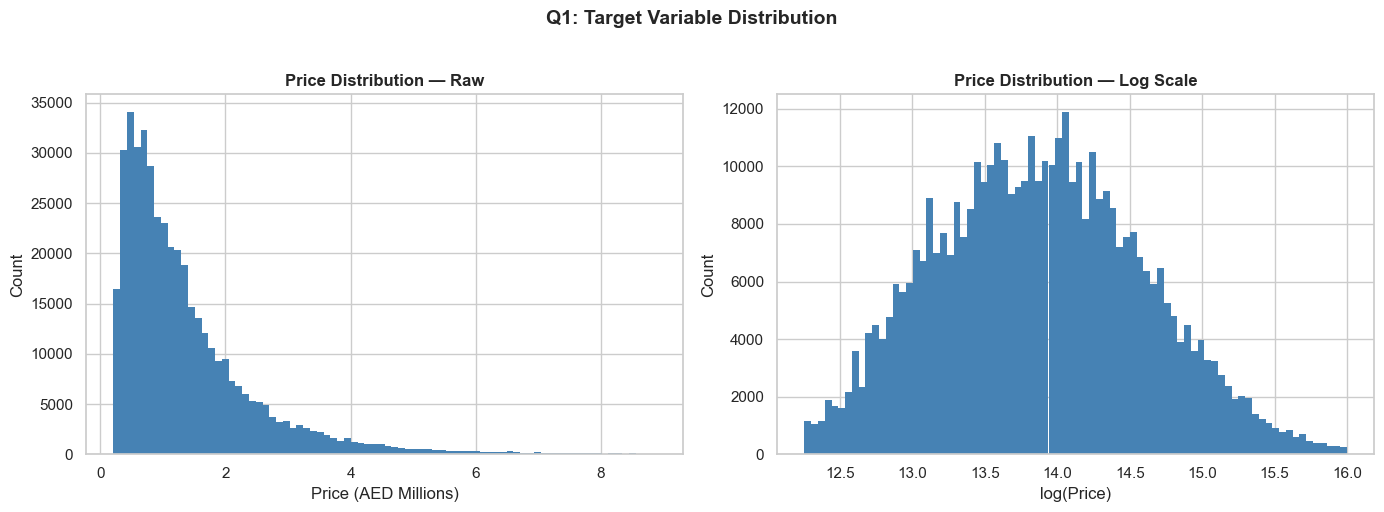

Decision: Log-transform the target before training (right-skewed → approx normal)


In [13]:
# ── Q1: What does the price distribution look like? ───────────────────────────
# Right-skewed distributions benefit from log transformation before modeling.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution — likely heavily right-skewed
axes[0].hist(df[TARGET] / 1e6, bins=80, color='steelblue', edgecolor='none')
axes[0].set_title('Price Distribution — Raw', fontweight='bold')
axes[0].set_xlabel('Price (AED Millions)')
axes[0].set_ylabel('Count')

# Log-transformed distribution — should look approximately normal
axes[1].hist(np.log1p(df[TARGET]), bins=80, color='steelblue', edgecolor='none')
axes[1].set_title('Price Distribution — Log Scale', fontweight='bold')
axes[1].set_xlabel('log(Price)')
axes[1].set_ylabel('Count')

plt.suptitle('Q1: Target Variable Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Decision: Log-transform the target before training (right-skewed → approx normal)')

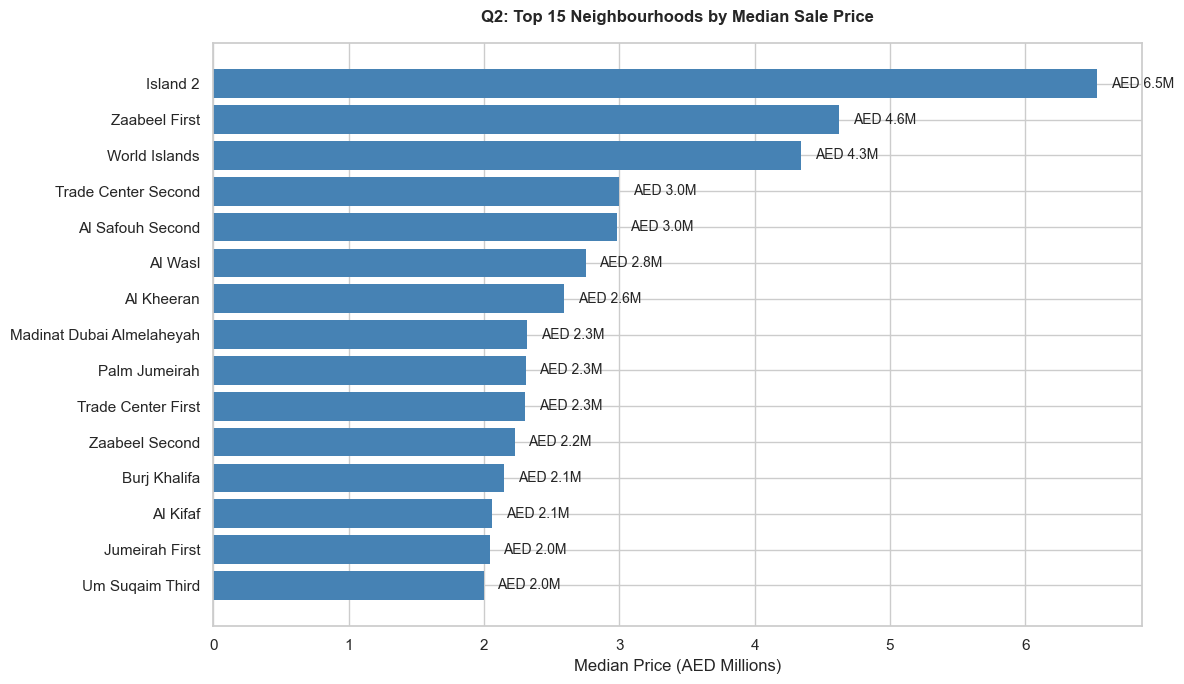

In [14]:
# ── Q2: Which neighbourhoods have the highest prices? ─────────────────────────
# area_name_en is our most important categorical feature — this validates that choice.

top_areas = (
    df.groupby('area_name_en')[TARGET]
    .median()
    .nlargest(15)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_areas.index, top_areas.values / 1e6, color='steelblue', edgecolor='none')

# Add value labels at end of each bar
for bar, val in zip(bars, top_areas.values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'AED {val/1e6:.1f}M', va='center', fontsize=10)

ax.set_title('Q2: Top 15 Neighbourhoods by Median Sale Price', fontweight='bold', pad=15)
ax.set_xlabel('Median Price (AED Millions)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('top_areas.png', dpi=150, bbox_inches='tight')
plt.show()

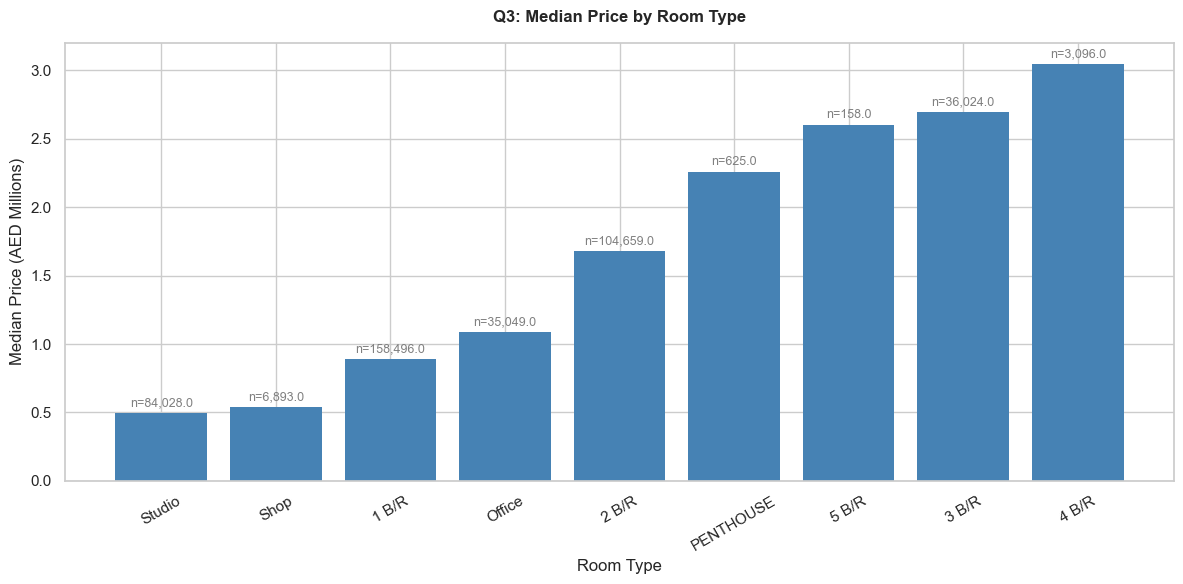

In [15]:
# ── Q3: How does room count affect price? ─────────────────────────────────────
# rooms_en is our second categorical feature — confirm it has a clear price signal.

# Get median price per room type, sorted by price
room_price = (
    df.groupby('rooms_en')[TARGET]
    .agg(['median', 'count'])
    .rename(columns={'median': 'median_price', 'count': 'transactions'})
    .query('transactions > 100')          # only room types with enough data
    .sort_values('median_price')
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(room_price.index, room_price['median_price'] / 1e6,
               color='steelblue', edgecolor='none')

# Annotate with transaction count
for bar, (_, row) in zip(bars, room_price.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'n={row["transactions"]:,}', ha='center', fontsize=9, color='gray')

ax.set_title('Q3: Median Price by Room Type', fontweight='bold', pad=15)
ax.set_xlabel('Room Type')
ax.set_ylabel('Median Price (AED Millions)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('price_by_rooms.png', dpi=150, bbox_inches='tight')
plt.show()

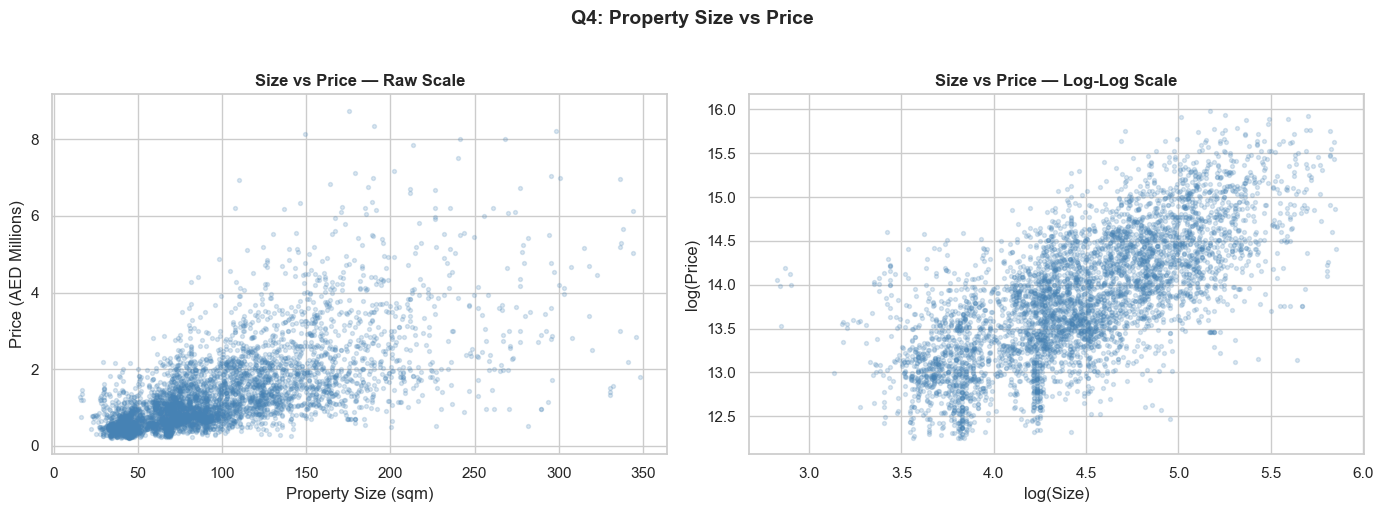

In [16]:
# ── Q4: Is there a clear relationship between size and price? ─────────────────
# procedure_area is our main numeric feature — verify it correlates with price.

# Sample 5000 points to avoid overplotting on large dataset
sample = df.sample(min(5000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw scale — likely a noisy fan shape
axes[0].scatter(sample['procedure_area'], sample[TARGET] / 1e6,
                alpha=0.2, s=8, color='steelblue')
axes[0].set_title('Size vs Price — Raw Scale', fontweight='bold')
axes[0].set_xlabel('Property Size (sqm)')
axes[0].set_ylabel('Price (AED Millions)')

# Log-log scale — should reveal a cleaner linear relationship
axes[1].scatter(np.log1p(sample['procedure_area']),
                np.log1p(sample[TARGET]),
                alpha=0.2, s=8, color='steelblue')
axes[1].set_title('Size vs Price — Log-Log Scale', fontweight='bold')
axes[1].set_xlabel('log(Size)')
axes[1].set_ylabel('log(Price)')

plt.suptitle('Q4: Property Size vs Price', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('size_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

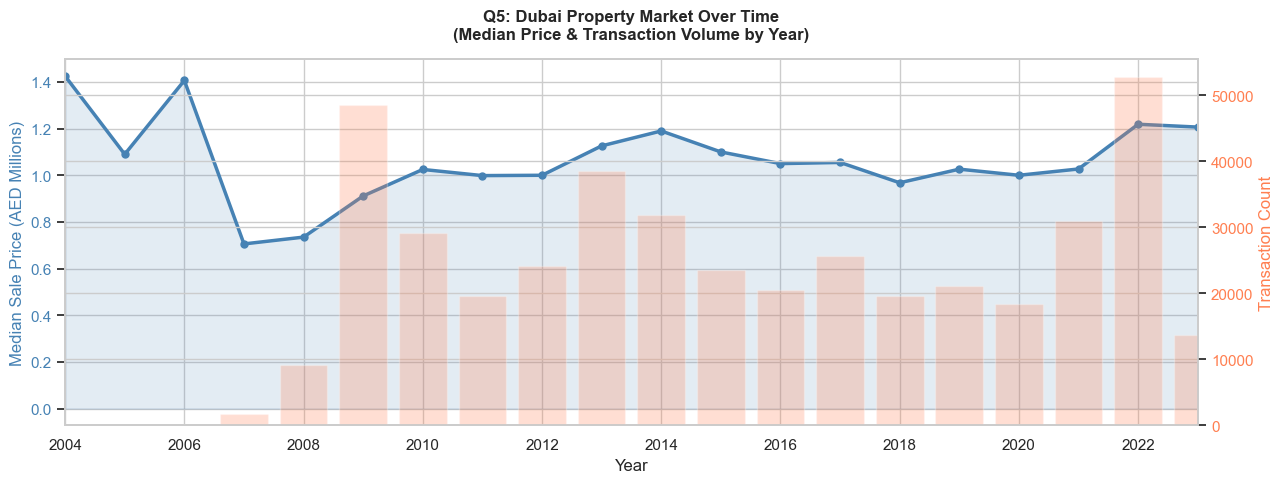

In [17]:
# ── Q5: How has the Dubai property market moved over time? ────────────────────
# year is our time feature — validate it captures market trends.

yearly = ( df.groupby('year')[TARGET]
    .agg(['median', 'count'])
    .rename(columns={'median': 'median_price', 'count': 'transactions'}) )

fig, ax1 = plt.subplots(figsize=(13, 5))

# Primary axis: median price trend
color_price = 'steelblue'

ax1.plot(
    yearly.index,
    yearly['median_price'] / 1e6,
    color=color_price,
    linewidth=2.5,
    marker='o',
    markersize=5
)

ax1.fill_between(
    yearly.index,
    yearly['median_price'] / 1e6,
    alpha=0.15,
    color=color_price
)

ax1.set_xlabel('Year')
ax1.set_ylabel('Median Sale Price (AED Millions)', color=color_price)
ax1.tick_params(axis='y', labelcolor=color_price)

# Force x-axis ticks every 2 years
ax1.xaxis.set_major_locator(mticker.MultipleLocator(2))

# Optional: make limits cleaner
ax1.set_xlim(yearly.index.min(), yearly.index.max())

# Secondary axis: transaction volume
ax2 = ax1.twinx()

color_vol = 'coral'

ax2.bar(
    yearly.index,
    yearly['transactions'],
    alpha=0.25,
    color=color_vol,
    label='Transaction Volume'
)

ax2.set_ylabel('Transaction Count', color=color_vol)
ax2.tick_params(axis='y', labelcolor=color_vol)

ax1.set_title(
    'Q5: Dubai Property Market Over Time\n'
    '(Median Price & Transaction Volume by Year)',
    fontweight='bold',
    pad=15
)

plt.tight_layout()
plt.savefig('market_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

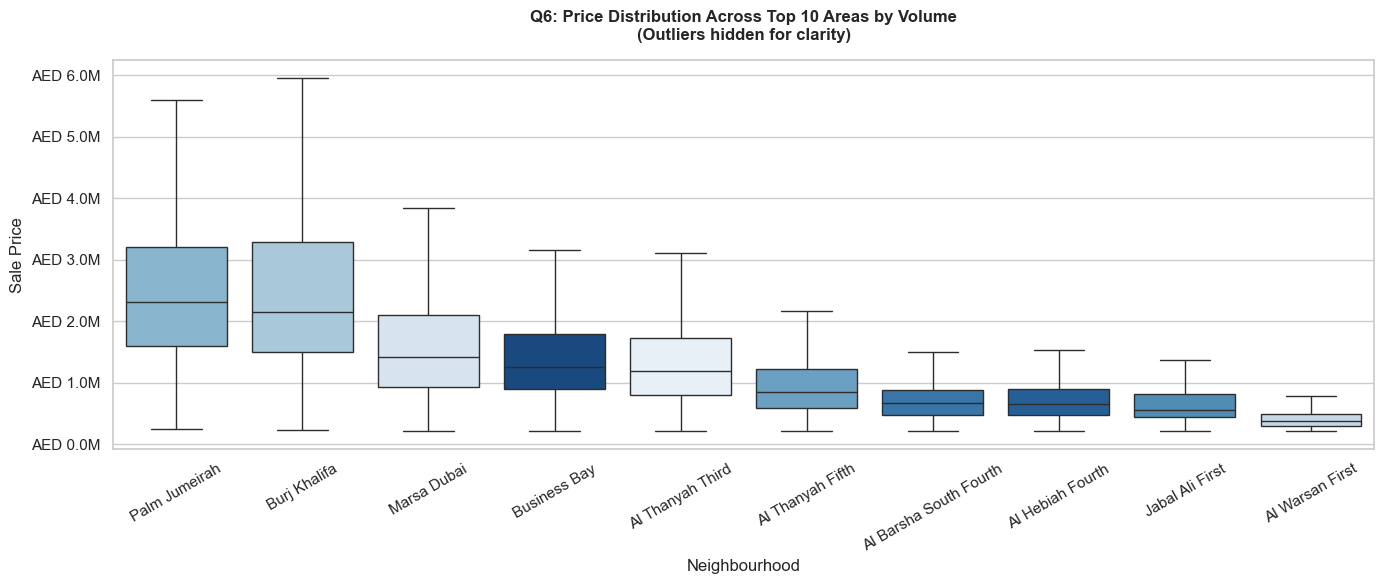

In [18]:
# ── Q6: Price distribution across top areas (box plot) ────────────────────────
# Shows spread and outliers per neighbourhood — richer than just median.

# Select top 10 areas by transaction count (enough data for reliable box plots)
top10_areas = (
    df['area_name_en']
    .value_counts()
    .head(10)
    .index.tolist()
)

df_top10 = df[df['area_name_en'].isin(top10_areas)].copy()

# Sort areas by median price for a clean ordered plot
order = (
    df_top10.groupby('area_name_en')[TARGET]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(
    data=df_top10,
    x='area_name_en',
    y=TARGET,
    hue='area_name_en',
    order=order,
    palette='Blues',
    showfliers=False,
    legend=False,        # hide extreme outliers for readability
    ax=ax
)

# Format y-axis in millions
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'AED {x/1e6:.1f}M'))
ax.set_title('Q6: Price Distribution Across Top 10 Areas by Volume\n(Outliers hidden for clarity)',
              fontweight='bold', pad=15)
ax.set_xlabel('Neighbourhood')
ax.set_ylabel('Sale Price')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('price_boxplot_areas.png', dpi=150, bbox_inches='tight')
plt.show()

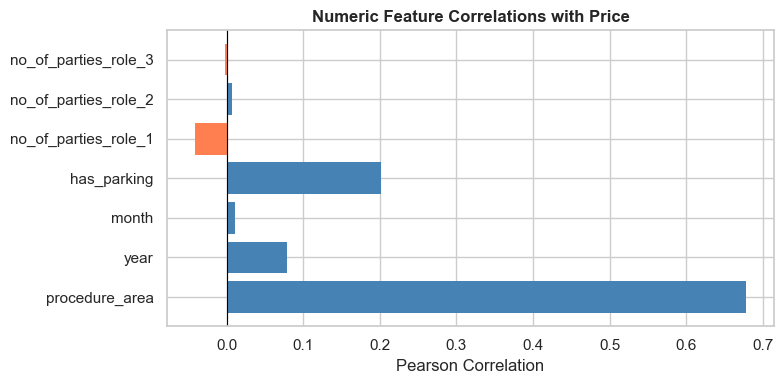

procedure_area          0.678858
year                    0.078554
month                   0.010731
has_parking             0.201214
no_of_parties_role_1   -0.042203
no_of_parties_role_2    0.006715
no_of_parties_role_3   -0.002177


In [19]:
# ── EDA Summary: numeric correlations with price ──────────────────────────────
# Quick check of how strongly each numeric feature correlates with the target.

corr = df[NUMERIC_FEATURES + [TARGET]].corr()[TARGET].drop(TARGET)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue' if v > 0 else 'coral' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors, edgecolor='none')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Numeric Feature Correlations with Price', fontweight='bold')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.savefig('correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print(corr.to_string())

## 9. Preprocessing Pipeline

We use sklearn's `Pipeline` + `ColumnTransformer` to bundle all preprocessing
with the model into a single object. This prevents data leakage and makes
deployment clean — the API just calls `pipeline.predict(input_df)`.

In [20]:
# ── Split features and target ─────────────────────────────────────────────────
X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]

# Log-transform the target — converts right-skewed distribution to approx normal.
# np.log1p(x) = log(x + 1), safe for x=0. Reverse with np.expm1() at inference.
y = np.log1p(df[TARGET])

# ── Train/test split ──────────────────────────────────────────────────────────
# 80% training, 20% held-out test set (never seen during training or CV)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train size : {X_train.shape[0]:,} rows')
print(f'Test size  : {X_test.shape[0]:,} rows')

Train size : 343,237 rows
Test size  : 85,810 rows


In [21]:
# ── Numeric sub-pipeline ──────────────────────────────────────────────────────
# Step 1: fill any remaining NaN with the median (robust to outliers vs mean)
# Step 2: scale to zero mean, unit variance (helps linear models; harmless for trees)
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

# ── Categorical sub-pipeline ──────────────────────────────────────────────────
# Step 1: fill NaN with the most common value
# Step 2: OrdinalEncoder converts strings to integers.
#         handle_unknown='use_encoded_value' + unknown_value=-1 means if the API
#         receives a neighbourhood not seen in training, it gets -1 (not a crash).
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1
    )),
])

# ── ColumnTransformer: apply each sub-pipeline to its columns ─────────────────
preprocessor = ColumnTransformer([
    ('num', numeric_transformer,     NUMERIC_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES),
])

print('Preprocessor built ✓')
preprocessor

Preprocessor built ✓


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['procedure_area', 'year', 'month',
                                  'has_parking', 'no_of_parties_role_1',
                                  'no_of_parties_role_2',
                                  'no_of_parties_role_3']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 ['area_name_en', 'rooms_en',
                                  'property_type_en', 'property_usage_en',
                                  'nearest_metro_en'])])

## 10. Model Comparison

We compare 5 models using 5-fold cross-validation on the training set.
CV score is our selection criterion — **not** test set performance (that's held for final evaluation only).

**Important:** each model gets its own pipeline variable so the final best model
is not accidentally overwritten.

In [22]:
# ── Define candidate models ───────────────────────────────────────────────────
CANDIDATE_MODELS = {
    'Linear Regression': LinearRegression(),

    'Ridge': Ridge(alpha=1.0),          # linear + L2 regularization

    'Decision Tree': DecisionTreeRegressor(
        max_depth=10,
        random_state=42
    ),

    'Random Forest': RandomForestRegressor(
    n_estimators=100,      # reduced from 200
    max_depth=15,          # limit tree depth — biggest memory saver
    max_samples=0.5,       # use only 50% of data per tree
    random_state=42,
    n_jobs=1,              # changed from -1 — don't parallelize across cores
    ),
    
    'XGBoost': XGBRegressor(
        objective='reg:squarederror',
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.5,         # reduced from 0.8 — uses less RAM per tree
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=1,              # changed from -1
        verbosity=0,
    )
}

# ── Run cross-validation for each model ───────────────────────────────────────
# Store results to pick the best model after the loop.
# Bug fix: we do NOT overwrite a shared `pipeline` variable here.
# Each model gets its own pipeline; results dict stores only the score.
cv_results = {}

print(f'{"Model":<22} {"CV R² Mean":>12} {"CV R² Std":>12}')
print('-' * 48)

for name, model in CANDIDATE_MODELS.items():
    # Wrap the shared preprocessor + this model into a pipeline
    candidate_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model',        model)
    ])

    # 5-fold CV — fits on 4 folds, scores on 1, repeats 5 times
    scores = cross_val_score(
        candidate_pipeline,
        X_train, y_train,
        cv=5,
        scoring='r2',
        n_jobs=-1
    )

    cv_results[name] = {'mean': scores.mean(), 'std': scores.std()}
    print(f'{name:<22} {scores.mean():>12.4f} {scores.std():>12.4f}')

print('-' * 48)

# ── Pick the best model by CV mean R² ────────────────────────────────────────
best_model_name = max(cv_results, key=lambda k: cv_results[k]['mean'])
print(f'\nBest model: {best_model_name} (CV R² = {cv_results[best_model_name]["mean"]:.4f})')

Model                    CV R² Mean    CV R² Std
------------------------------------------------
Linear Regression            0.6281       0.0018
Ridge                        0.6281       0.0018
Decision Tree                0.8130       0.0011
Random Forest                0.8793       0.0008
XGBoost                      0.8569       0.0015
------------------------------------------------

Best model: Random Forest (CV R² = 0.8793)


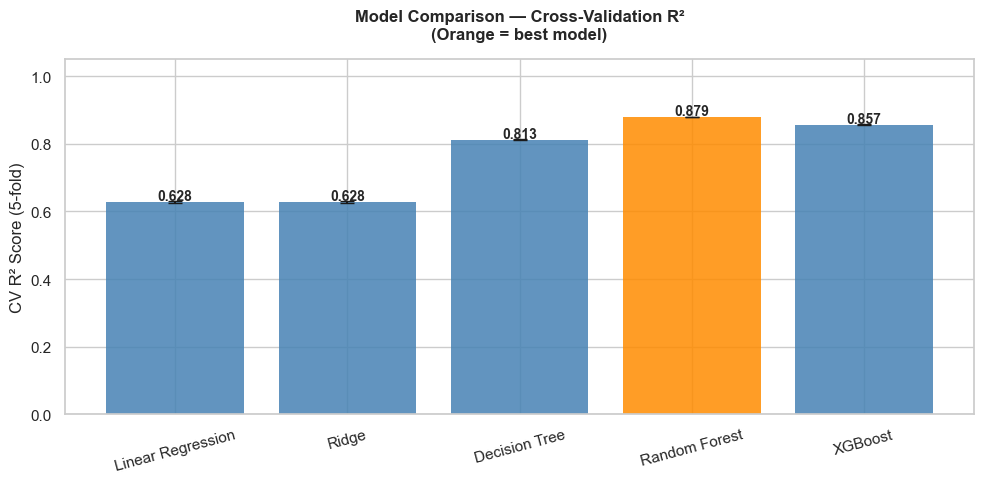

In [23]:
# ── Visualize model comparison ────────────────────────────────────────────────
names  = list(cv_results.keys())
means  = [cv_results[n]['mean'] for n in names]
stds   = [cv_results[n]['std']  for n in names]
colors = ['steelblue' if n != best_model_name else 'darkorange' for n in names]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(names, means, yerr=stds, capsize=5,
               color=colors, edgecolor='none', alpha=0.85)

# Label each bar with its score
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{mean:.3f}', ha='center', fontsize=10, fontweight='bold')

ax.set_ylim(0, 1.05)
ax.set_ylabel('CV R² Score (5-fold)')
ax.set_title('Model Comparison — Cross-Validation R²\n(Orange = best model)',
              fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Final Model — Train, Evaluate & Save

We retrain the best model on the **full training set** and evaluate once
on the **held-out test set**. This is the honest, final performance estimate.

In [24]:
# ── Build final pipeline with the best model ──────────────────────────────────
# Use the model name selected above — no hardcoding needed.
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',        CANDIDATE_MODELS[best_model_name])
])

# ── Fit on the full training set ──────────────────────────────────────────────
print(f'Training {best_model_name} on {X_train.shape[0]:,} samples...')
final_pipeline.fit(X_train, y_train)
print('Training complete ✓')

Training Random Forest on 343,237 samples...
Training complete ✓


In [25]:
# ── Evaluate on the held-out test set ────────────────────────────────────────
# Predict in log scale, then convert back to AED for interpretable metrics.

y_pred_log = final_pipeline.predict(X_test)

# Reverse log transform: expm1(x) = exp(x) - 1, the inverse of log1p
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

# ── Metrics ───────────────────────────────────────────────────────────────────
mae  = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)

# Mean Absolute Percentage Error — intuitive: avg % off per prediction
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print('── Test Set Metrics ──────────────────────────')
print(f'  R²         : {r2:.4f}   (1.0 = perfect)')
print(f'  MAE  (AED) : {mae:>15,.0f}')
print(f'  RMSE (AED) : {rmse:>15,.0f}')
print(f'  MAPE       : {mape:.2f}%  (avg % error per prediction)')

── Test Set Metrics ──────────────────────────
  R²         : 0.8460   (1.0 = perfect)
  MAE  (AED) :         242,667
  RMSE (AED) : 195,393,467,734
  MAPE       : 18.07%  (avg % error per prediction)


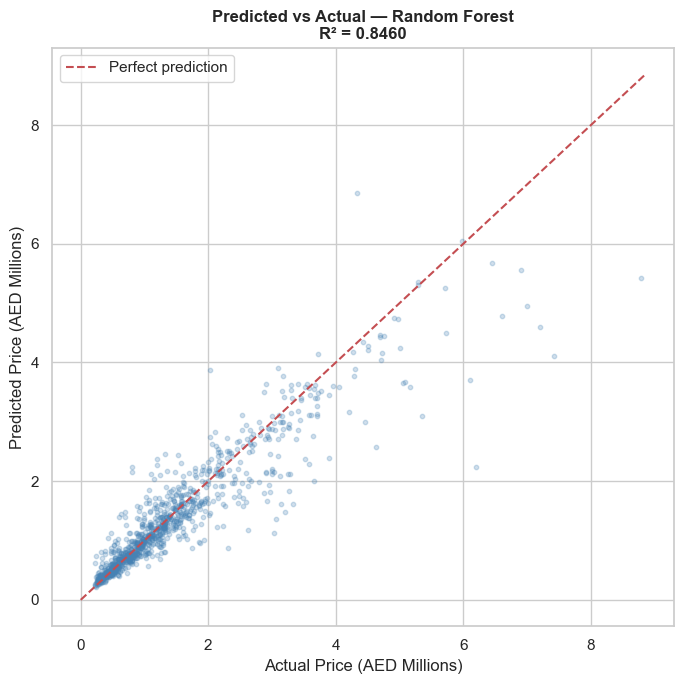

In [26]:
# ── Predicted vs Actual plot ───────────────────────────────────────────────────
# Points close to the red diagonal line = good predictions.
# Systematic deviation = model bias.

sample_idx = np.random.choice(len(y_true), size=min(1000, len(y_true)), replace=False)

# y_true is a pandas Series; y_pred is a numpy array — index carefully
y_true_arr = y_true.values

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_true_arr[sample_idx] / 1e6, y_pred[sample_idx] / 1e6,
            alpha=0.25, s=10, color='steelblue')

# Perfect prediction line (y = x)
max_val = max(y_true_arr.max(), y_pred.max()) / 1e6
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect prediction')

ax.set_xlabel('Actual Price (AED Millions)')
ax.set_ylabel('Predicted Price (AED Millions)')
ax.set_title(f'Predicted vs Actual — {best_model_name}\nR² = {r2:.4f}',
              fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

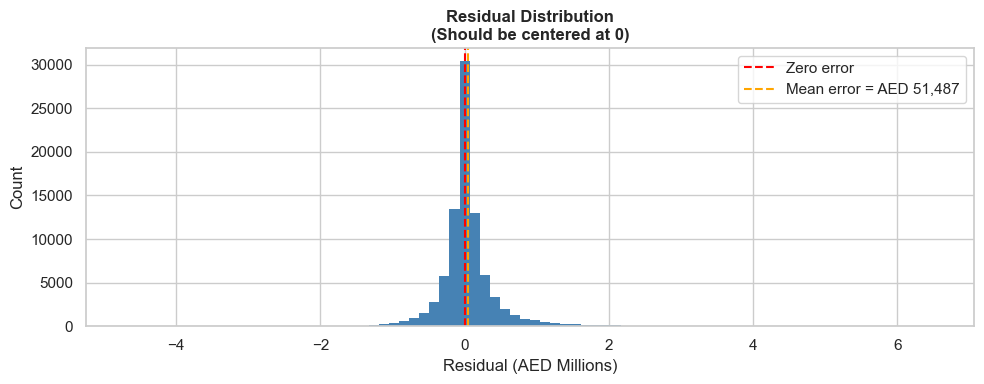

In [27]:
# ── Residual distribution plot ─────────────────────────────────────────────────
# Residuals = actual - predicted. Should be centered around 0.
# A skewed residual plot reveals systematic bias.

residuals = y_true_arr - y_pred

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(residuals / 1e6, bins=80, color='steelblue', edgecolor='none')
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
ax.axvline(residuals.mean() / 1e6, color='orange', linestyle='--',
            linewidth=1.5, label=f'Mean error = AED {residuals.mean():,.0f}')
ax.set_xlabel('Residual (AED Millions)')
ax.set_ylabel('Count')
ax.set_title('Residual Distribution\n(Should be centered at 0)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('residuals.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# ── Save model + metadata ─────────────────────────────────────────────────────
# joblib is preferred over pickle for sklearn pipelines — handles numpy arrays better.
joblib.dump(final_pipeline, MODEL_PATH)
print(f'Model saved → {MODEL_PATH}')

# Save metadata: features, transform info, and all metrics.
# This JSON is committed to GitHub so results are visible without running the notebook.
meta = {
    'model':            best_model_name,
    'features': {
        'numeric':      NUMERIC_FEATURES,
        'categorical':  CATEGORICAL_FEATURES,
    },
    'target':           TARGET,
    'target_transform': 'log1p / expm1',
    'cv_r2_mean':       round(cv_results[best_model_name]['mean'], 4),
    'cv_r2_std':        round(cv_results[best_model_name]['std'],  4),
    'test_R2':          round(r2,   4),
    'test_MAE_AED':     round(mae,  2),
    'test_RMSE_AED':    round(rmse, 2),
    'test_MAPE_pct':    round(mape, 2),
}

with open(META_PATH, 'w') as f:
    json.dump(meta, f, indent=2)

print(f'Metadata saved → {META_PATH}')
print(json.dumps(meta, indent=2))

Model saved → D:\dubai-property-predictor\models\model.joblib
Metadata saved → D:\dubai-property-predictor\models\model_meta.json
{
  "model": "Random Forest",
  "features": {
    "numeric": [
      "procedure_area",
      "year",
      "month",
      "has_parking",
      "no_of_parties_role_1",
      "no_of_parties_role_2",
      "no_of_parties_role_3"
    ],
    "categorical": [
      "area_name_en",
      "rooms_en",
      "property_type_en",
      "property_usage_en",
      "nearest_metro_en"
    ]
  },
  "target": "actual_worth",
  "target_transform": "log1p / expm1",
  "cv_r2_mean": 0.8793,
  "cv_r2_std": 0.0008,
  "test_R2": 0.846,
  "test_MAE_AED": 242667.32,
  "test_RMSE_AED": 195393467734.24,
  "test_MAPE_pct": 18.07
}


In [29]:
# Use a 30% sample just for the learning curve — result is representative enough
X_lc, _, y_lc, _ = train_test_split(X_train, y_train, train_size=0.3, random_state=42)

train_sizes, train_scores, cv_scores_lc = learning_curve(
    final_pipeline,
    X_lc, y_lc,           # sampled data
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=1,
)

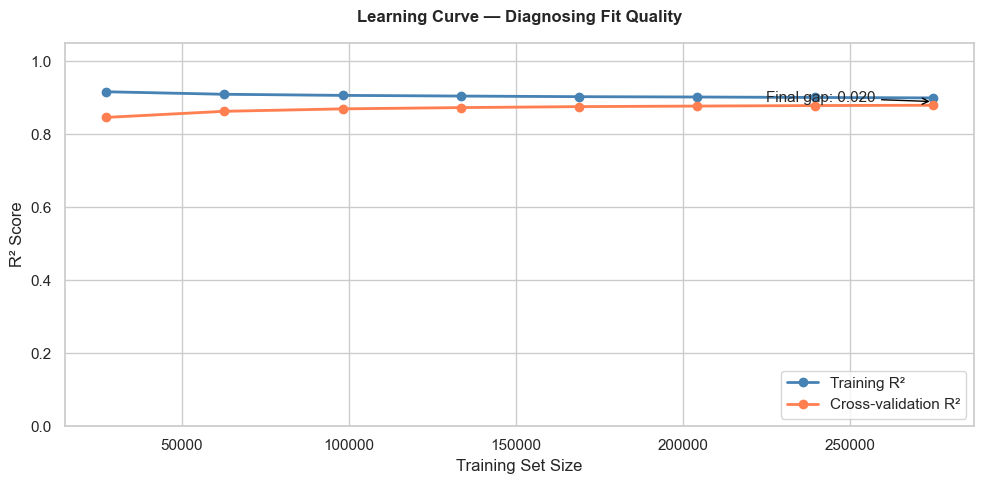

In [30]:
# Trains on increasing portions of training data and scores both train and CV.
# The gap between the two lines tells you what's happening:
#   - Train high, CV low, big gap  → OVERFITTING
#   - Both low, small gap          → UNDERFITTING  
#   - Both high, small gap         → WELL-FITTED ✓

train_sizes, train_scores, cv_scores_lc = learning_curve(
    final_pipeline,
    X_train, y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8),  # 8 points from 8% to 100% of data
    n_jobs=-1
)

# Compute mean and std across the 5 folds at each training size
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
cv_mean    = cv_scores_lc.mean(axis=1)
cv_std     = cv_scores_lc.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))

# Training score line
ax.plot(train_sizes, train_mean, 'o-', color='steelblue',
        linewidth=2, label='Training R²')
ax.fill_between(train_sizes,
                train_mean - train_std,
                train_mean + train_std,
                alpha=0.15, color='steelblue')

# Cross-validation score line
ax.plot(train_sizes, cv_mean, 'o-', color='coral',
        linewidth=2, label='Cross-validation R²')
ax.fill_between(train_sizes,
                cv_mean - cv_std,
                cv_mean + cv_std,
                alpha=0.15, color='coral')

ax.set_xlabel('Training Set Size')
ax.set_ylabel('R² Score')
ax.set_title('Learning Curve — Diagnosing Fit Quality', fontweight='bold', pad=15)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)

# Annotate final gap
gap = train_mean[-1] - cv_mean[-1]
ax.annotate(f'Final gap: {gap:.3f}',
            xy=(train_sizes[-1], (train_mean[-1] + cv_mean[-1]) / 2),
            xytext=(-120, 0), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=11)

plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# ── Automatic diagnosis based on the scores ───────────────────────────────────
train_final = train_mean[-1]   # training R² at full data
cv_final    = cv_mean[-1]      # CV R² at full data
gap         = train_final - cv_final

print('── Fit Diagnosis ──────────────────────────────────')
print(f'  Training R²        : {train_final:.4f}')
print(f'  Cross-val R²       : {cv_final:.4f}')
print(f'  Gap (train - CV)   : {gap:.4f}')
print()

if train_final < 0.75:
    print('  ⚠️  UNDERFITTING')
    print('  Both scores are low. The model is too simple.')
    print('  Try: more features, deeper trees, more estimators.')

elif gap > 0.10:
    print('  ⚠️  OVERFITTING')
    print('  Training score is much higher than CV score.')
    print('  Try: reduce max_depth, increase min_samples_leaf,')
    print('       lower n_estimators, add more training data.')

else:
    print('  ✅  WELL-FITTED')
    print('  Training and CV scores are close and both high.')
    print('  The model generalizes well to unseen data.')

print('──────────────────────────────────────────────────')

── Fit Diagnosis ──────────────────────────────────
  Training R²        : 0.8995
  Cross-val R²       : 0.8793
  Gap (train - CV)   : 0.0201

  ✅  WELL-FITTED
  Training and CV scores are close and both high.
  The model generalizes well to unseen data.
──────────────────────────────────────────────────


## 12. Sanity Check — Predict One Property

Test the saved pipeline end-to-end with a realistic Dubai Marina 2BR apartment.

In [32]:
# ── Build a single-row input DataFrame ───────────────────────────────────────
# Column names and types must exactly match what the pipeline was trained on.
# Bug fix: removed 'nearest_metro_en' which was dropped from features.

sample_input = pd.DataFrame([{
    # Numeric features
    'procedure_area':       120.0,   # 120 sqm apartment
    'year':                 2024,
    'month':                3,
    'has_parking':          1,       # 1 = has parking, 0 = no parking
    'no_of_parties_role_1': 1.0,     # typically 1 seller
    'no_of_parties_role_2': 1.0,     # typically 1 buyer
    'no_of_parties_role_3': 0.0,     # usually 0

    # Categorical features
    'area_name_en':         'Dubai Marina',
    'rooms_en':             '2 B/R',
    'property_type_en':     'Unit',
    'property_usage_en':    'Residential',
    'nearest_metro_en':     'DAMAC Properties',
}])

log_pred = final_pipeline.predict(sample_input)[0]
price    = np.expm1(log_pred)

print('── Sample Prediction ──────────────────────────')
print(f'  Input  : 120 sqm, 2BR, Dubai Marina, March 2024')
print(f'  Output : AED {price:,.0f}')
print(f'  Per sqm: AED {price/120:,.0f}/sqm')

── Sample Prediction ──────────────────────────
  Input  : 120 sqm, 2BR, Dubai Marina, March 2024
  Output : AED 1,254,031
  Per sqm: AED 10,450/sqm


In [33]:
# ── Test a few more properties to sense-check the model ──────────────────────
test_cases = [
    {
        'procedure_area': 45, 'year': 2024, 'month': 1,
        'has_parking': 0, 'no_of_parties_role_1': 1.0,
        'no_of_parties_role_2': 1.0, 'no_of_parties_role_3': 0.0,
        'area_name_en': 'International City', 'rooms_en': 'Studio',
        'property_type_en': 'Unit', 'property_usage_en': 'Residential',
        'nearest_metro_en': 'Emirates',
    },
    {
        'procedure_area': 80, 'year': 2024, 'month': 6,
        'has_parking': 1, 'no_of_parties_role_1': 1.0,
        'no_of_parties_role_2': 1.0, 'no_of_parties_role_3': 0.0,
        'area_name_en': 'Downtown Dubai', 'rooms_en': '1 B/R',
        'property_type_en': 'Unit', 'property_usage_en': 'Residential',
        'nearest_metro_en': 'Burj Khalifa/Dubai Mall',
    },
    {
        'procedure_area': 180, 'year': 2024, 'month': 9,
        'has_parking': 1, 'no_of_parties_role_1': 1.0,
        'no_of_parties_role_2': 1.0, 'no_of_parties_role_3': 0.0,
        'area_name_en': 'Palm Jumeirah', 'rooms_en': '3 B/R',
        'property_type_en': 'Unit', 'property_usage_en': 'Residential',
        'nearest_metro_en': 'Nakheel',
    },
]

print(f'{"Area":<22} {"Type":<10} {"Sqm":>6} {"Predicted Price":>20} {"Per Sqm":>14}')
print('-' * 76)

for case in test_cases:
    inp   = pd.DataFrame([case])
    price = np.expm1(final_pipeline.predict(inp)[0])
    sqm   = case['procedure_area']
    print(f'{case["area_name_en"]:<22} {case["rooms_en"]:<10} {sqm:>6} '
          f'AED {price:>15,.0f}   AED {price/sqm:>8,.0f}/sqm')

Area                   Type          Sqm      Predicted Price        Per Sqm
----------------------------------------------------------------------------
International City     Studio         45 AED         689,029   AED   15,312/sqm
Downtown Dubai         1 B/R          80 AED         825,086   AED   10,314/sqm
Palm Jumeirah          3 B/R         180 AED       1,945,717   AED   10,810/sqm
